<a href="https://colab.research.google.com/github/atmanainapure/NYC-Motor-Vehicle-Collisions/blob/main/Final_TDSP_Atman_Ainapure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  **<font color='lightblue'>** **Submission - Atman Ainapure**</font>


---



## <font color='lightblue'>**Milestone #1 - Data Preparation**</font>

  

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

**Let’s access our data.**

We will be using the [NYC OpenData Motor Vehicle Collisions - Crashes dataset](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95). According to NYC Open Data, "each row represents a crash event."

We will query the data using the SODA API endpoint so as to not have to download it and upload it to Google Drive.

In [ ]:
import requests
import pandas as pd

# The SODA3 API endpoint specific to the NYC Motor Vehicle Collisions dataset
url = "https://data.cityofnewyork.us/api/v3/views/h9gi-nx95/query.json"

# Signed up for an app token through this website.
# https://dev.socrata.com/foundry/data.cityofnewyork.us/h9gi-nx95
headers = {
    "X-App-Token": "YOUR API KEY" # Note: INSERT YOUR GENERATED TOKEN
}
# Pagination is explicitly defined to bypass the API's default 1,000-row limit.
# The pageSize is capped at 50,000 to prevent Google Colab from crashing.
payload = {
    "query": "SELECT *",
    "page": {
        "pageNumber": 1,
        "pageSize": 50000
    }
}


### Why I Am Using **50,000** Rows

The original NYC crashes dataset contains approximately **2.27 million rows**. For this stage of the analysis, I am working with a **50,000-row sample** rather than loading the entire dataset into Google Colab.

- **Memory management:** Loading 2.27 million rows can consume a large amount of RAM and may cause the Colab session to slow down or crash.

- **Faster development:** 50,000 rows is large enough to test data cleaning, preprocessing, visualizations, and exploratory analysis without waiting several minutes for each cell to run.

- **Efficient workflow:** It is more practical to develop and test the analysis on a smaller sample first. Once the code and methodology are working correctly, the same process can be scaled to the full dataset.

- **Representative sample:** The 50,000 rows provide a manageable subset of the full dataset for initial exploration. However, I will keep in mind that results from this sample may not perfectly represent all 2.27 million crash records.


In [ ]:
response = requests.post(url, headers=headers, json=payload)
if response.status_code == 200:
    data = response.json()
    df = pd.DataFrame(data)
    # Display the first 5 rows to visually verify the dataset loaded correctly
    display(df.head())
else:
    # output the exact error code and server message for debugging
    print(f"Failed to fetch data. Status Code: {response.status_code}")
    print(response.text)

,crash_date,crash_time,borough,zip_code,latitude,longitude,location,cross_street_name,number_of_persons_injured,number_of_persons_killed,...,:created_at,:updated_at,on_street_name,off_street_name,contributing_factor_vehicle_3,vehicle_type_code_3,contributing_factor_vehicle_4,vehicle_type_code_4,contributing_factor_vehicle_5,vehicle_type_code_5
0,2021-04-13T00:00:00.000,0:00,BROOKLYN,11222,40.7264440,-73.9523300,"{'latitude': 40.726444, 'longitude': -73.95233}",745 MANHATTAN AVENUE,0,0,...,2021-04-19T13:00:42.446Z,2021-04-19T13:01:20.786Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-04-13T00:00:00.000,0:00,BROOKLYN,11231,40.6785240,-74.0021000,"{'latitude': 40.678524, 'longitude': -74.0021}",667 HENRY STREET,0,0,...,2021-04-19T13:00:42.446Z,2021-04-19T13:01:20.786Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-04-13T00:00:00.000,0:00,QUEENS,11420,40.6774980,-73.8276000,"{'latitude': 40.677498, 'longitude': -73.8276}",NaN,0,0,...,2021-04-19T13:00:42.446Z,2021-04-19T13:01:20.786Z,111 STREET,ROCKAWAY BOULEVARD,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-04-13T00:00:00.000,0:00,NaN,NaN,NaN,NaN,NaN,NaN,0,0,...,2021-04-19T13:00:42.446Z,2021-04-19T13:01:20.786Z,ALEXANDER HAMILTON BRIDGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-04-13T00:00:00.000,0:00,NaN,NaN,40.8772350,-73.9178100,"{'latitude': 40.877235, 'longitude': -73.91781}",NaN,0,0,...,2021-04-19T13:00:42.446Z,2021-04-19T13:01:20.786Z,JOHNSON AVENUE,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Calculate the summary for numerical columns
summary_stats = df.describe()
display(summary_stats)

,crash_date,crash_time,borough,zip_code,latitude,longitude,location,cross_street_name,number_of_persons_injured,number_of_persons_killed,...,:created_at,:updated_at,on_street_name,off_street_name,contributing_factor_vehicle_3,vehicle_type_code_3,contributing_factor_vehicle_4,vehicle_type_code_4,contributing_factor_vehicle_5,vehicle_type_code_5
count,50000,50000,32251,32248,46111,46111,46111,13355,49999,50000,...,50000,50000,36645,22885,5172,4846,1431,1371,443,434
unique,185,1438,5,192,23497,19718,28018,12305,13,3,...,1,43,3535,3782,24,58,12,23,8,16
top,2020-10-30T00:00:00.000,0:00,BROOKLYN,11207,0E-7,0E-7,"{'latitude': 0.0, 'longitude': 0.0}",355 FOOD CENTER DRIVE,0,0,...,2021-04-19T13:00:42.446Z,2021-04-19T13:01:37.549Z,BELT PARKWAY,BROADWAY,Unspecified,Sedan,Unspecified,Sedan,Unspecified,Sedan
freq,394,825,11456,881,503,503,493,11,34267,49880,...,50000,16214,898,195,4836,2426,1353,715,414,217


### <font color='lightblue'>**Exploratory Data Analysis: Initial Observations**</font>

Based on the summary statistics generated by `df.describe()`, several key data quality issues and trends are evident in this 50,000-row sample:

*   **Missing Neighborhood Data:** Approximately 35% of the records lack specific neighborhood labels. While the dataset contains 50,000 rows, the `borough` and `zip_code` columns only have ~32k non-null entries.
*   **Coordinate Entry Errors:** The most frequent latitude and longitude values are `0.0` (occurring 503 times). These must be filtered before geospatial mapping.
*   **Time Defaulting:** The most common crash time is `0:00` (midnight), occurring 825 times. This spike suggests that officers or data clerks default to midnight when the exact time of an incident is unknown.
*   **Primary Hotspots:** In this specific slice of data, **Brooklyn** is the most frequently recorded borough (11,456 incidents), and the **Belt Parkway** is the most common specific street location.
*   **Low-Severity Baselines:** The vast majority of incidents are minor property-damage accidents. Out of 50,000 records, 34,267 reported `0` persons injured, and 49,880 reported `0` persons killed.
*   **Vague Multi-Vehicle Reporting:** For secondary vehicles in larger crashes (Vehicles 3, 4, and 5), the most common vehicle type is "Sedan", but the contributing factor is largely logged as "Unspecified". Investigators likely focus their detailed reporting on the primary two vehicles involved.


### <font color='lightblue'>**A Quick Note on Performance: CPU vs. T4 GPU**</font>
My Observation

Initially, I was running this on the CPU without the T4 GPU runtime enabled in Google Colab, so the cell (summary_stats = df.describe()) was taking much longer than expected. After looking into the cause of the delay, I switched the runtime to a T4 GPU and enabled the high-RAM option available with Colab Pro. The same cell then completed in under two minutes. This made it clear that the computation was better suited to a GPU-based runtime, especially given the size of the data and the processing involved.

-------------------

## <font color='lightblue'>**Milestone #2: Data Ethics, Pre-Processing, and Exploration**</font>

### **Well-Resourced vs. Under-Resourced Communities**

* **Human Bias in Collection:** Even when the analysis is automated, people decide where and how data is collected. Those decisions can unintentionally introduce bias.

* **Over-representation:** Well-resourced communities often have better monitoring infrastructure, such as traffic cameras, and higher rates of official reporting.

* **Under-representation:** Under-resourced communities may have more unreported incidents because of limited infrastructure, mistrust of law enforcement, or concerns about insurance costs.

* **Impact:** Missing data can make the dataset less representative and introduce bias into the analysis and any estimates derived from it.

### **How Bias Shows Up in the NYC Crashes Dataset**

* **Skewed Safety Metrics:** Minor crashes may be more likely to be documented in wealthier areas because residents are more likely to report them for insurance purposes. Similar incidents may go unreported in lower-income areas.

* **Missing Geospatial Data:** Areas with less reporting infrastructure may depend more heavily on manual data collection. This could contribute to missing values in fields such as `zip_code` or `borough`.

* **Risks of Blind Data Cleaning:** Simply deleting every row with missing values could disproportionately remove crash records from under-resourced neighborhoods. The cleaned dataset could then give a misleading picture of road safety by representing well-resourced communities more heavily.


#### **1. Count the Missing Values**

Before deciding what to drop or keep, lets see exactly which columns are missing data. This directly relates to the under-reporting bias discussed in the ethics section.

In [ ]:
# Calculate the total number of missing (null) values in each column
missing_data = df.isna().sum()

# Calculate the percentage of missing data per column
missing_percentage = (missing_data / len(df)) * 100

# Combine them into a new DataFrame for easy viewing
missing_summary = pd.DataFrame({
    'Missing Values': missing_data,
    'Percentage (%)': missing_percentage
})

# Sort to see the columns with the most missing data at the top
display(missing_summary.sort_values(by='Percentage (%)', ascending=False))

,Missing Values,Percentage (%)
vehicle_type_code_5,49566,99.132
contributing_factor_vehicle_5,49557,99.114
vehicle_type_code_4,48629,97.258
contributing_factor_vehicle_4,48569,97.138
vehicle_type_code_3,45154,90.308
contributing_factor_vehicle_3,44828,89.656
cross_street_name,36645,73.290
off_street_name,27115,54.230
zip_code,17752,35.504
borough,17749,35.498


#### **2. Fix the "Null Island" Coordinate Error**

As discovered in the describe() output, many crashes have a latitude and longitude of 0.0. If we leave these as 0.0, they might be termed as valid locations. We must hence convert them to proper null values (NaN) so they are treated as missing data.

In [ ]:
import numpy as np
import pandas as pd

# 1. Convert the text columns into numeric (floats).
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

# 2. replace 0.0 with NaN.
df['latitude'] = df['latitude'].replace(0.0, np.nan)
df['longitude'] = df['longitude'].replace(0.0, np.nan)
display(df[['latitude', 'longitude']].describe())

,latitude,longitude
count,45608.000000,45608.000000
mean,40.725221,-73.913109
std,0.083188,0.083736
min,40.503070,-74.251150
25%,40.665541,-73.958002
50%,40.713318,-73.917076
75%,40.792725,-73.866234
max,40.912884,-73.701500


Finally, evaluating the new minimum and maximum values confirms they align with the real-world geographic boundaries of New York City:

Latitude Bounds: The minimum (40.50) aligns with the southern tip of Staten Island, and the maximum (40.91) aligns with the northern border of the Bronx.

Longitude Bounds: The minimum (-74.25) marks the western edge of Staten Island, and the maximum (-73.70) marks the eastern edge of Queens.

#### **3. Convert Data Types (Dates and Times)**
The API likely imported the dates and times as standard text (strings). To analyze crashes by month, day of the week, or hour, we have to convert these columns into pandas datetime objects.

In [ ]:
# === BEFORE VIEW ===
print("--- BEFORE CONVERSION ---")
print("Data Types:")
print(df[['crash_date', 'crash_time']].dtypes)
print("\nFirst 2 Rows:")
display(df[['crash_date', 'crash_time']].head(7))
print("\n" + "="*40 + "\n")

# === THE CONVERSION ===
# Convert crash_date to datetime
df['crash_date'] = pd.to_datetime(df['crash_date'])

# Convert crash_time to a proper time format
df['crash_time'] = pd.to_datetime(df['crash_time'], format='mixed').dt.time

# === AFTER VIEW ===
print("--- AFTER CONVERSION ---")
print("Data Types:")
print(df[['crash_date', 'crash_time']].dtypes)
print("\nFirst 2 Rows:")
display(df[['crash_date', 'crash_time']].head(7))

--- BEFORE CONVERSION ---
Data Types:
crash_date    datetime64[ns]
crash_time            object
dtype: object

First 2 Rows:


,crash_date,crash_time
0,2021-04-13,0:00
1,2021-04-13,0:00
2,2021-04-13,0:00
3,2021-04-13,0:00
4,2021-04-13,0:00
5,2021-04-13,0:00
6,2021-04-13,0:07




--- AFTER CONVERSION ---
Data Types:
crash_date    datetime64[ns]
crash_time            object
dtype: object

First 2 Rows:


,crash_date,crash_time
0,2021-04-13,00:00:00
1,2021-04-13,00:00:00
2,2021-04-13,00:00:00
3,2021-04-13,00:00:00
4,2021-04-13,00:00:00
5,2021-04-13,00:00:00
6,2021-04-13,00:07:00


#### **4. Handle the Remaining Missing Data**

We have previously counted the missing values. Since its established in the ethics section that blindly dropping rows can introduce bias, one should fill missing categorical text with a placeholder. In this case, UNSPECIFIED.

In [ ]:
# Define the columns we want to clean
columns_to_fill = ['borough', 'zip_code', 'on_street_name', 'cross_street_name', 'off_street_name']

# Ensure we only try to clean columns that actually exist in your DataFrame
existing_cols = [col for col in columns_to_fill if col in df.columns]

# === BEFORE VIEW ===
print("--- BEFORE FILLING ---")
print("Count of missing values:")
display(df[existing_cols].isna().sum())
print("\n" + "="*40 + "\n")

# === THE CLEANING PROCESS ===
# Fill any blank (NaN) cells in these specific columns with the text 'UNSPECIFIED'
for col in existing_cols:
    df[col] = df[col].fillna('UNSPECIFIED')

# === AFTER VIEW ===
print("--- AFTER FILLING ---")
print("Count of missing values:")
display(df[existing_cols].isna().sum())

# Show a quick preview of the actual text changes in the first 5 rows
print("\nFirst 5 rows (notice the 'UNSPECIFIED' text):")
display(df[existing_cols].head())

--- BEFORE FILLING ---
Count of missing values:


,0
borough,0
zip_code,0
on_street_name,0
cross_street_name,0
off_street_name,0




--- AFTER FILLING ---
Count of missing values:


,0
borough,0
zip_code,0
on_street_name,0
cross_street_name,0
off_street_name,0



First 5 rows (notice the 'UNSPECIFIED' text):


,borough,zip_code,on_street_name,cross_street_name,off_street_name
0,BROOKLYN,11222,UNSPECIFIED,745 MANHATTAN AVENUE,UNSPECIFIED
1,BROOKLYN,11231,UNSPECIFIED,667 HENRY STREET,UNSPECIFIED
2,QUEENS,11420,111 STREET,UNSPECIFIED,ROCKAWAY BOULEVARD
3,UNSPECIFIED,UNSPECIFIED,ALEXANDER HAMILTON BRIDGE,UNSPECIFIED,UNSPECIFIED
4,UNSPECIFIED,UNSPECIFIED,JOHNSON AVENUE,UNSPECIFIED,UNSPECIFIED


#### **5. Check for and Remove Duplicates**

duplicate data can distort your distributions and mislead your analysis.

In [ ]:
# Drop the dictionary-based 'location' column if it exists
if 'location' in df.columns:
    df = df.drop(columns=['location'])

# Now run the duplicate check again
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# If there are duplicates, drop them and keep the first occurrence
if duplicate_count > 0:
    df = df.drop_duplicates(keep='first')
    print(f"Duplicates removed. New dataset shape: {df.shape}")

Number of duplicate rows: 0


### <font color='lightblue'>**Exploratory Analysis: Time, Causes, and Borough-Level Injuries**</font>

We will now create three visualizations to explore different aspects of the NYC crash dataset.

First, lets extract the **hour of the day** from `crash_time` and count the number of crashes occurring during each hour. This helps identify whether crashes are concentrated around particular times of the day.

Next, I will examine the **contributing factors** recorded for each crash. I exclude records marked as `Unspecified` because they do not provide a meaningful explanation for the crash, and then identify the 10 most frequently reported known causes.

Finally, I group the data by **borough** and calculate the total number of persons injured in each borough.

The three charts then present these results as:
1. A **line chart** showing crashes by hour of the day.
2. A **horizontal bar chart** showing the 10 most common known contributing factors.
3. A **bar chart** comparing total reported injuries across NYC boroughs.

### **Conclusion**
Together, these visualizations give an initial view of **when crashes occur, what factors are most commonly associated with them, and where the largest number of reported injuries occurred** in the sample.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate crashes by hour
df['crash_hour'] = df['crash_time'].apply(lambda x: x.hour if pd.notna(x) else None)
crashes_by_hour = df['crash_hour'].value_counts().sort_index()

# Calculate top causes (excluding 'Unspecified')
top_causes = df[df['contributing_factor_vehicle_1'] != 'Unspecified']['contributing_factor_vehicle_1'].value_counts().head(10)

# Calculate casualties by borough
df['number_of_persons_injured'] = pd.to_numeric(df['number_of_persons_injured'], errors='coerce')
casualty_summary = df.groupby('borough')[['number_of_persons_injured']].sum().sort_values(by='number_of_persons_injured', ascending=False)



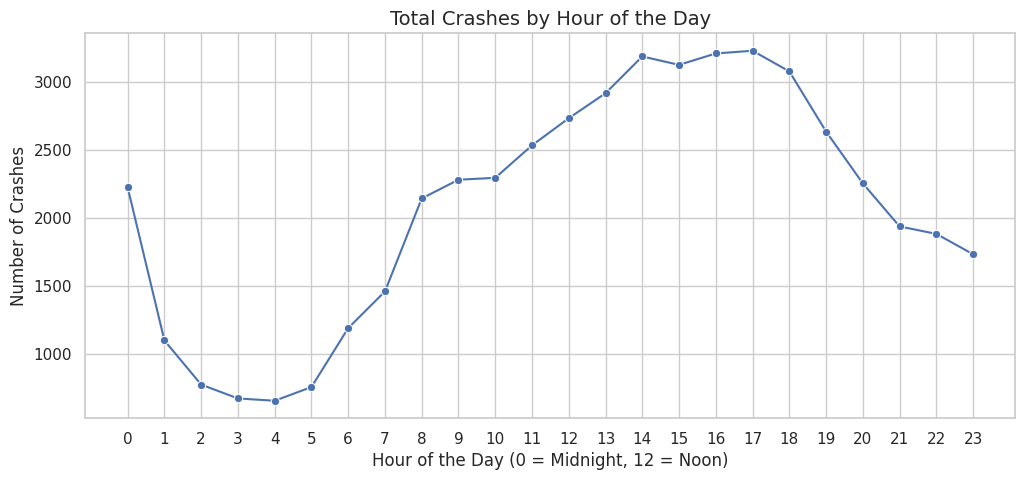

In [ ]:

# ==========================================
# Generate the Visualizations
# ==========================================
sns.set_theme(style="whitegrid")

# Chart 1: Temporal Trend (Crashes by Hour)
plt.figure(figsize=(12, 5))
sns.lineplot(x=crashes_by_hour.index, y=crashes_by_hour.values, marker="o", color="b")
plt.title("Total Crashes by Hour of the Day", fontsize=14)
plt.xlabel("Hour of the Day (0 = Midnight, 12 = Noon)", fontsize=12)
plt.ylabel("Number of Crashes", fontsize=12)
plt.xticks(range(0, 24))
plt.show()

### Conclusion

Crash frequency is lowest in the early morning and rises sharply after 6 AM, peaking around 4-5 PM. The data shows that afternoon and evening hours carry the highest crash volume, while overnight hours see far fewer crashes.

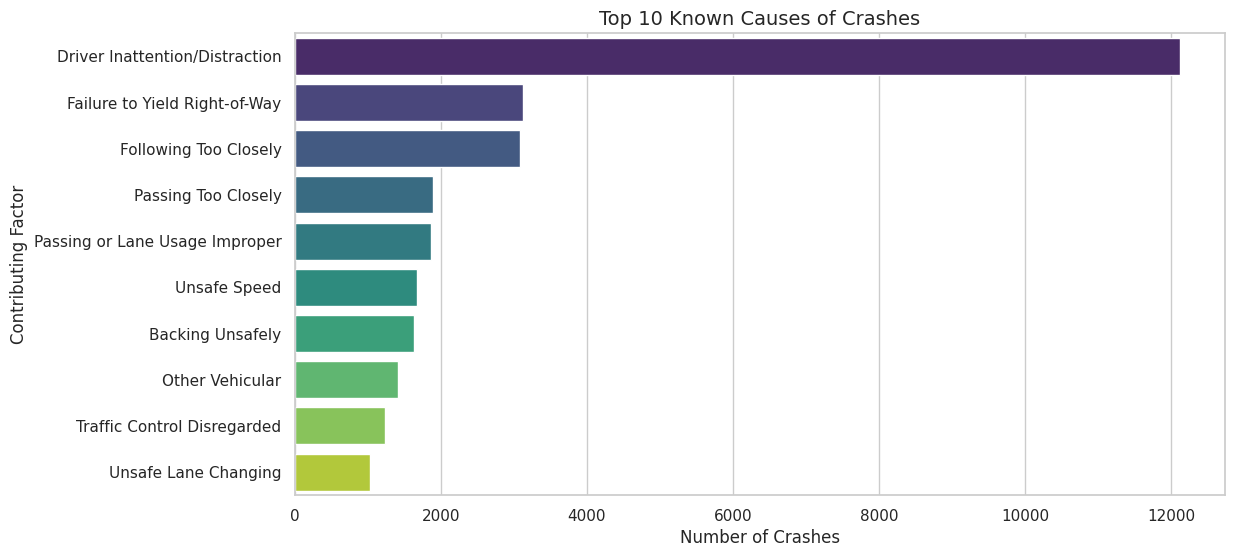

In [ ]:
# Chart 2: Top Causes (Horizontal Bar Chart)
plt.figure(figsize=(12, 6))
# Using orient='h' to ensure seaborn knows it's a horizontal barplot
sns.barplot(x=top_causes.values, y=top_causes.index, hue=top_causes.index, legend=False, palette="viridis")
plt.title("Top 10 Known Causes of Crashes", fontsize=14)
plt.xlabel("Number of Crashes", fontsize=12)
plt.ylabel("Contributing Factor", fontsize=12)
plt.show()

### Top 3 contributing factors:

Driver Inattention/Distraction: ~12,100 crashes
Failure to Yield Right-of-Way: ~3,100 crashes
Following Too Closely: ~3,000 crashes

### Recommendations for drivers

Stay focused: Put the phone away and avoid anything that takes your attention off the road.

Give others the right-of-way: Slow down at intersections and check carefully before turning or merging.

Keep a safe following distance: Leave enough space to react if the vehicle ahead suddenly brakes.

Key takeaway: The largest contributor by far is driver distraction, making attentive and defensive driving one of the clearest areas for prevention.

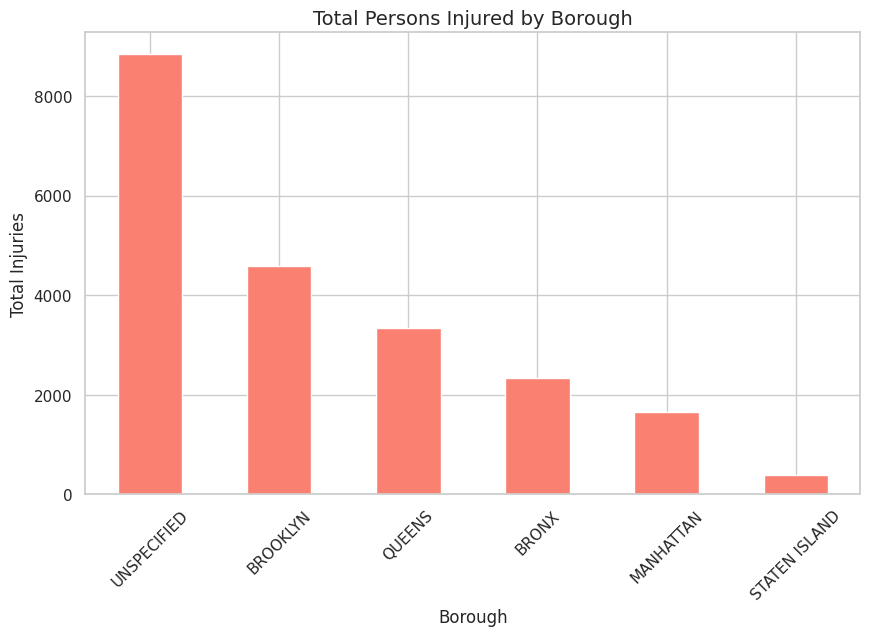

In [ ]:
# Chart 3: Casualties by Borough (Vertical Bar Chart)
plt.figure(figsize=(10, 6))
casualty_summary['number_of_persons_injured'].plot(kind='bar', color='salmon')
plt.title("Total Persons Injured by Borough", fontsize=14)
plt.xlabel("Borough", fontsize=12)
plt.ylabel("Total Injuries", fontsize=12)
plt.xticks(rotation=45)
plt.show()

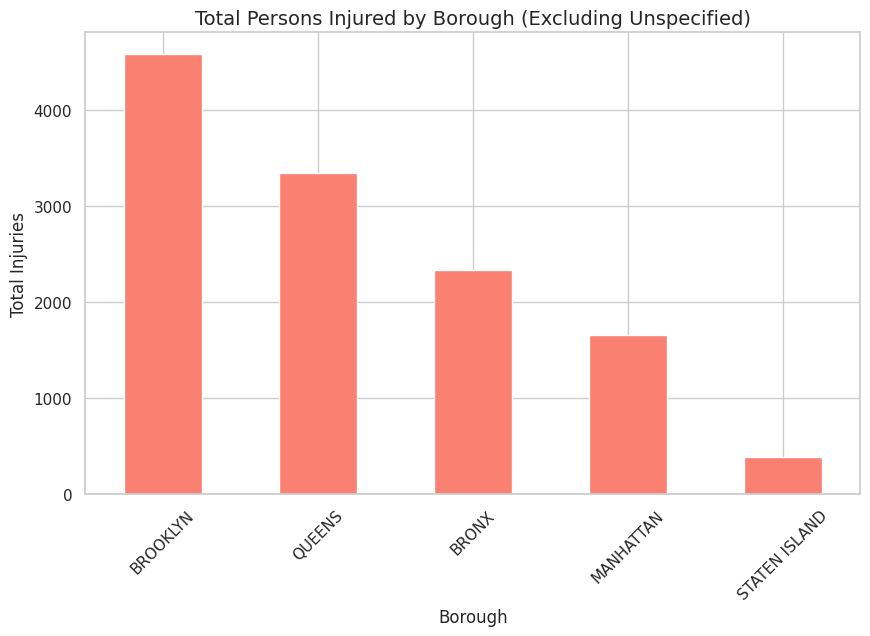

In [ ]:
# Filter out the 'UNSPECIFIED' category from the borough column
filtered_df = df[df['borough'] != 'UNSPECIFIED']
casualty_summary_filtered = filtered_df.groupby('borough')[['number_of_persons_injured']].sum().sort_values(by='number_of_persons_injured', ascending=False)
plt.figure(figsize=(10, 6))
casualty_summary_filtered['number_of_persons_injured'].plot(kind='bar', color='salmon')
plt.title("Total Persons Injured by Borough (Excluding Unspecified)", fontsize=14)
plt.xlabel("Borough", fontsize=12)
plt.ylabel("Total Injuries", fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [ ]:
# ==========================================
# Chart 4: Top 10 Vehicle Types in Crashes
# ==========================================
# Using 'vehicle_type_code_1', which represents the primary vehicle involved.
# We exclude 'Unspecified'

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
sns.set_theme(style="whitegrid")
if 'vehicle_type_code_1' in df.columns:
    top_vehicles = df[df['vehicle_type_code_1'] != 'Unspecified']['vehicle_type_code_1'].value_counts().head(10)

    plt.figure(figsize=(12, 6))
    # Horizontal bar chart to accommodate long vehicle names (like "Station Wagon/Sport Utility Vehicle")
    sns.barplot(x=top_vehicles.values, y=top_vehicles.index, hue=top_vehicles.index, legend=False, palette="mako")
    plt.title("Top 10 Primary Vehicle Types Involved in Crashes", fontsize=14)
    plt.xlabel("Number of Crashes", fontsize=12)
    plt.ylabel("Vehicle Type", fontsize=12)
    plt.show()
else:
    print("Column 'vehicle_type_code_1' not found in dataset.")


Column 'vehicle_type_code_1' not found in dataset.


In [ ]:
# Print all columns
print(df.columns.tolist())

['crash_date', 'crash_time', 'borough', 'zip_code', 'latitude', 'longitude', 'cross_street_name', 'number_of_persons_injured', 'number_of_persons_killed', 'number_of_pedestrians_injured', 'number_of_pedestrians_killed', 'number_of_cyclist_injured', 'number_of_cyclist_killed', 'number_of_motorist_injured', 'number_of_motorist_killed', 'contributing_factor_vehicle_1', 'contributing_factor_vehicle_2', 'collision_id', 'vehicle_type_code1', 'vehicle_type_code2', ':id', ':version', ':created_at', ':updated_at', 'on_street_name', 'off_street_name', 'contributing_factor_vehicle_3', 'vehicle_type_code_3', 'contributing_factor_vehicle_4', 'vehicle_type_code_4', 'contributing_factor_vehicle_5', 'vehicle_type_code_5', 'crash_hour', 'crash_type']


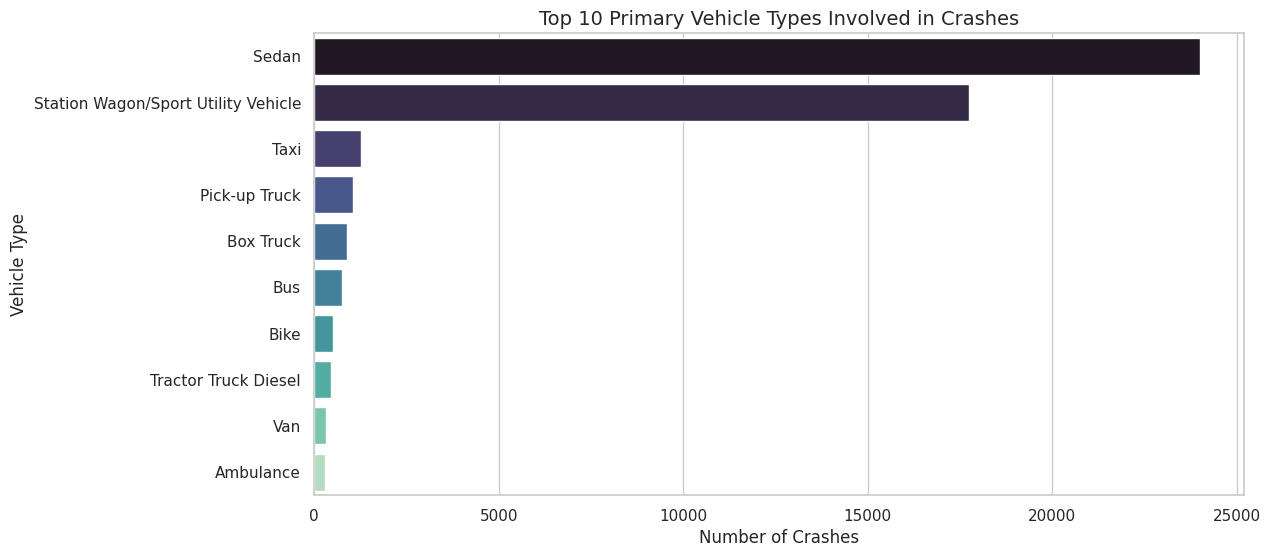

In [ ]:
# We use vehicle_type_code1 instead of vehicle_type_code_1
sns.set_theme(style="whitegrid")
if 'vehicle_type_code1' in df.columns:
    top_vehicles = df[df['vehicle_type_code1'] != 'Unspecified']['vehicle_type_code1'].value_counts().head(10)

    plt.figure(figsize=(12, 6))
    # Horizontal bar chart to accommodate long vehicle names (like "Station Wagon/Sport Utility Vehicle")
    sns.barplot(x=top_vehicles.values, y=top_vehicles.index, hue=top_vehicles.index, legend=False, palette="mako")
    plt.title("Top 10 Primary Vehicle Types Involved in Crashes", fontsize=14)
    plt.xlabel("Number of Crashes", fontsize=12)
    plt.ylabel("Vehicle Type", fontsize=12)
    plt.show()
else:
    print("Column 'vehicle_type_code1' not found in dataset.")


### Top 3 vehicles involved in crashes

Sedan: ~24,000 crashes

Station Wagon/Sport Utility Vehicle: ~17,500 crashes

Taxi: ~1,200 crashes


### Other conclusions

There is a large gap between the top two vehicle categories and the rest.
The chart shows how many crashes involved each vehicle type, not how dangerous each vehicle type is. A high count could simply reflect that there are more sedans on the road.

This analysis uses a 50,000-row sample from a dataset of 2.27 million crash records. The chart shows patterns within this sample, so the findings should be **treated as indicative rather than representative** of the entire dataset.

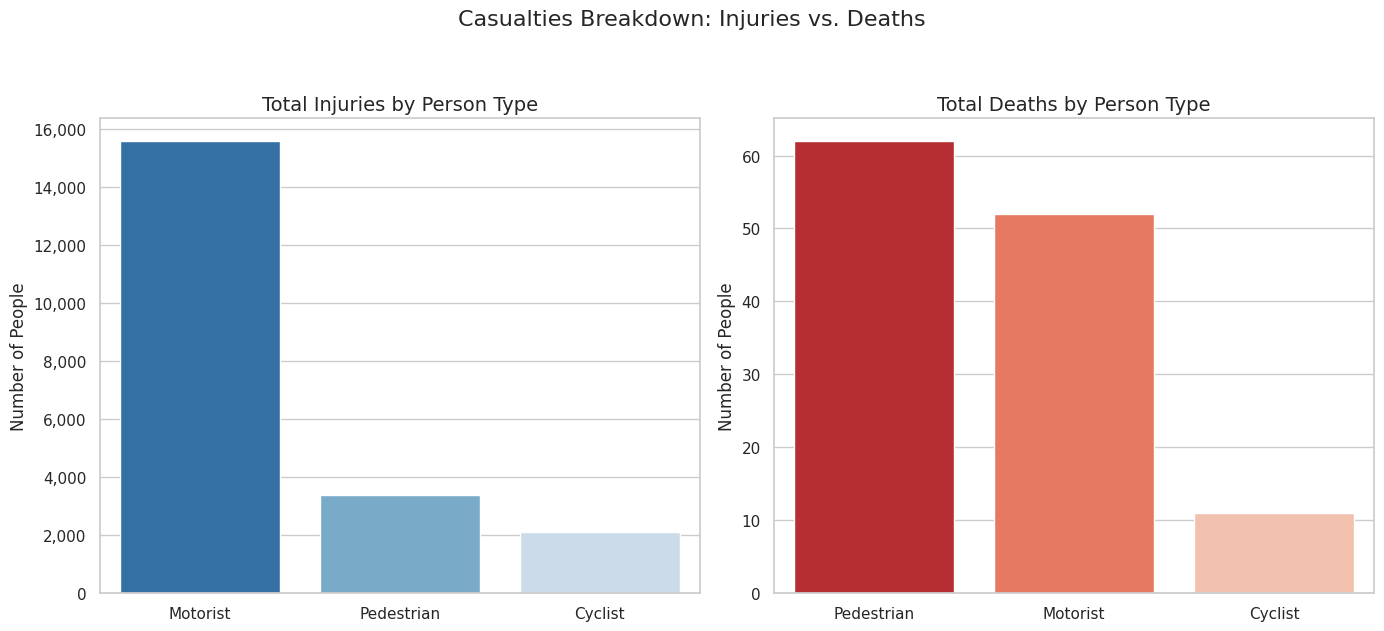

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Organize the data into two separate dataframes for easy plotting
injury_data = {
    'Person Type': ['Motorist', 'Pedestrian', 'Cyclist'],
    'Count': [
        df['number_of_motorist_injured'].sum(),
        df['number_of_pedestrians_injured'].sum(),
        df['number_of_cyclist_injured'].sum()
    ]
}

death_data = {
    'Person Type': ['Motorist', 'Pedestrian', 'Cyclist'],
    'Count': [
        df['number_of_motorist_killed'].sum(),
        df['number_of_pedestrians_killed'].sum(),
        df['number_of_cyclist_killed'].sum()
    ]
}

df_injuries = pd.DataFrame(injury_data).sort_values(by='Count', ascending=False)
df_deaths = pd.DataFrame(death_data).sort_values(by='Count', ascending=False)

# 2. Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Injuries (Left side)
sns.barplot(x='Person Type', y='Count', data=df_injuries, ax=axes[0], palette='Blues_r', hue='Person Type', legend=False)
axes[0].set_title('Total Injuries by Person Type', fontsize=14)
axes[0].set_ylabel('Number of People', fontsize=12)
axes[0].set_xlabel('')
# Format Y-axis with commas
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

# Plot 2: Deaths (Right side)
sns.barplot(x='Person Type', y='Count', data=df_deaths, ax=axes[1], palette='Reds_r', hue='Person Type', legend=False)
axes[1].set_title('Total Deaths by Person Type', fontsize=14)
axes[1].set_ylabel('Number of People', fontsize=12)
axes[1].set_xlabel('')

# Add a main title for the whole figure
plt.suptitle('Casualties Breakdown: Injuries vs. Deaths', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### For citizens

Motorists account for most injuries, but pedestrians make up the largest number of deaths in this sample. Drivers should stay alert around pedestrians and cyclists, while pedestrians and cyclists should remain visible and use designated crossings and lanes where available.

### For the Department of Transportation

The injury and death patterns suggest that pedestrian safety deserves particular attention. The department could use this data to identify high-risk locations and assess measures such as safer crossings, pedestrian signals, lighting, and traffic-calming measures.

-----------------------------
##<font color='lightblue'> **Milestone #3 - Time Series Analysis**</font>
GOAL: The main goal of this milestone is to dive deeper into Time Series Analysis in order to better understand our data's trends over time.

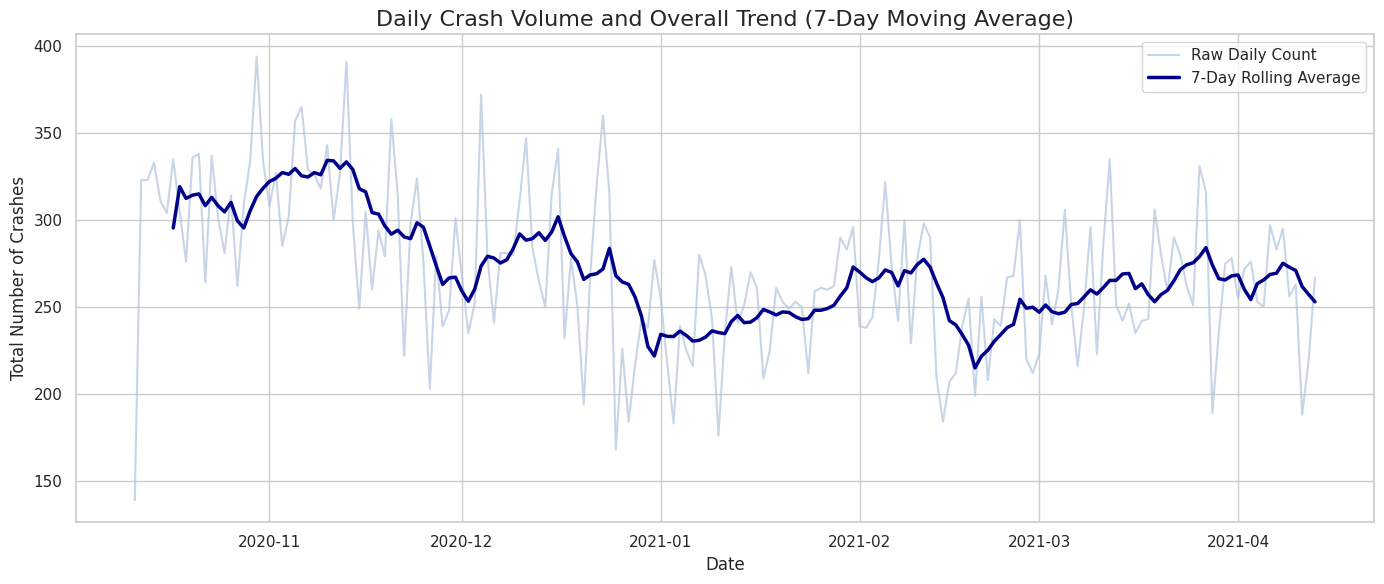

Data spans from 2020-10-11 to 2021-04-13


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# date as the index and sorting it chronologically
# Sorting is critical for TSA
tsa_df = df.set_index('crash_date').sort_index()
# 2. Resample the data by Day ('D') to get the total number of crashes per day
daily_crashes = tsa_df.resample('D').size()
# This averages out the past 7 days for every single point to smooth the line
rolling_7d = daily_crashes.rolling(window=7).mean()
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")
# Plot the raw daily counts in the background (light grey)
sns.lineplot(x=daily_crashes.index, y=daily_crashes.values, color='lightsteelblue', label='Raw Daily Count', alpha=0.7)
# Plot the smoothed 7-day rolling average in the foreground (bold blue)
sns.lineplot(x=rolling_7d.index, y=rolling_7d.values, color='darkblue', label='7-Day Rolling Average', linewidth=2.5)
plt.title("Daily Crash Volume and Overall Trend (7-Day Moving Average)", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Number of Crashes", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# Print the date range of the sample to provide context for the chart
print(f"Data spans from {daily_crashes.index.min().date()} to {daily_crashes.index.max().date()}")

### Conclusion

I approached this visualization similarly to stock market charts, where the daily movement can be noisy, but a moving average makes the underlying trend easier to see. Applying a 7-day rolling average to crash data reveals that crash volume was highest in late 2020, declined into January 2021, and gradually recovered through March.

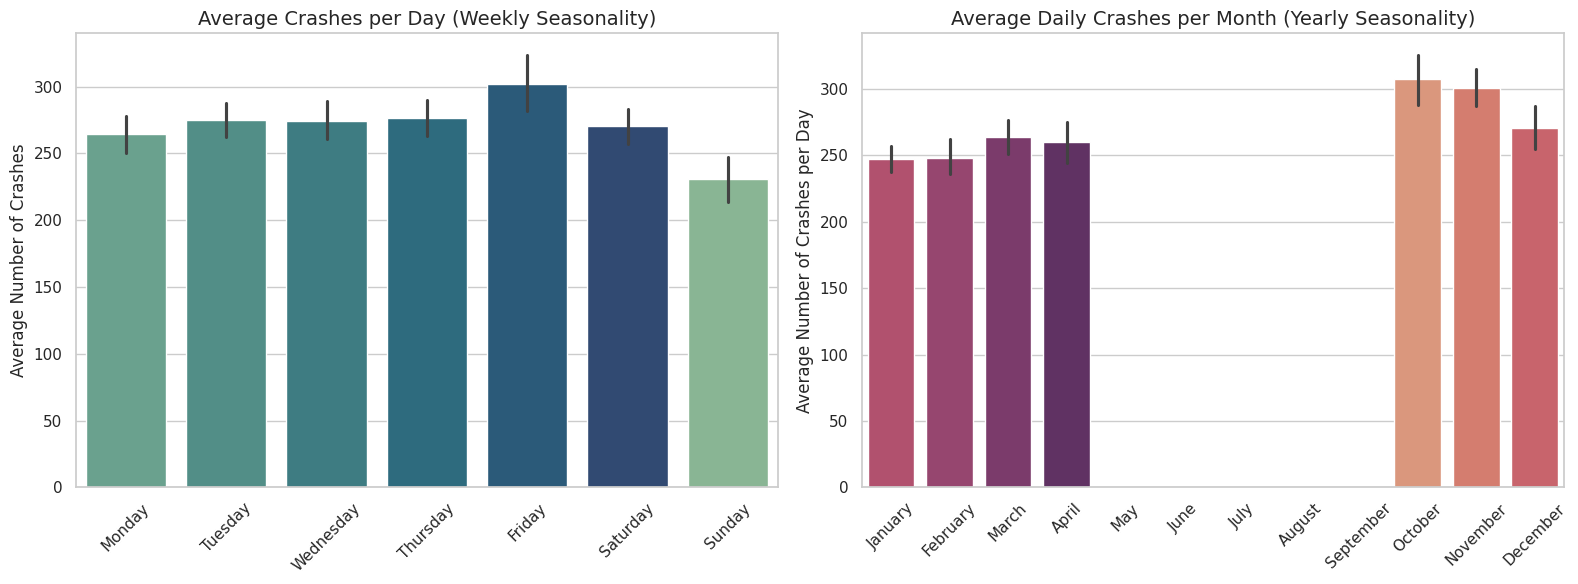

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import calendar

# 1. Count the exact number of crashes that happened on every single specific date
daily_counts = df.groupby('crash_date').size().reset_index(name='daily_crash_count')
daily_counts['day_of_week'] = daily_counts['crash_date'].dt.day_name()
daily_counts['month'] = daily_counts['crash_date'].dt.month_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
months_order = list(calendar.month_name)[1:]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# ==========================================
# Chart 1: Day of the Week Seasonality
# ==========================================
sns.barplot(
    x='day_of_week', y='daily_crash_count', data=daily_counts,
    order=days_order, ax=axes[0], palette="crest", hue='day_of_week', legend=False
)
axes[0].set_title("Average Crashes per Day (Weekly Seasonality)", fontsize=14)
axes[0].set_ylabel("Average Number of Crashes", fontsize=12)
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=45)

# ==========================================
# Chart 2: Monthly Seasonality
# ==========================================
sns.barplot(
    x='month', y='daily_crash_count', data=daily_counts,
    order=months_order, ax=axes[1], palette="flare", hue='month', legend=False
)
axes[1].set_title("Average Daily Crashes per Month (Yearly Seasonality)", fontsize=14)
axes[1].set_ylabel("Average Number of Crashes per Day", fontsize=12)
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Conclusion

Crashes show a clear weekly pattern, with **Friday** having the highest average and Sunday the lowest. The monthly pattern also varies, with **September–November** showing higher average crash volumes in the available data.

Side note: This analysis uses only 50,000 rows from 2.27 million records, and some months have no observations in the sample. The monthly pattern should therefore be treated as indicative, not representative of the full dataset.

## TREND in Time Series Analysis


Trend in Time Series Analysis (TSA) refers to the overall long-term direction of the data, showing whether values are generally increasing, decreasing, or remaining stable over time.

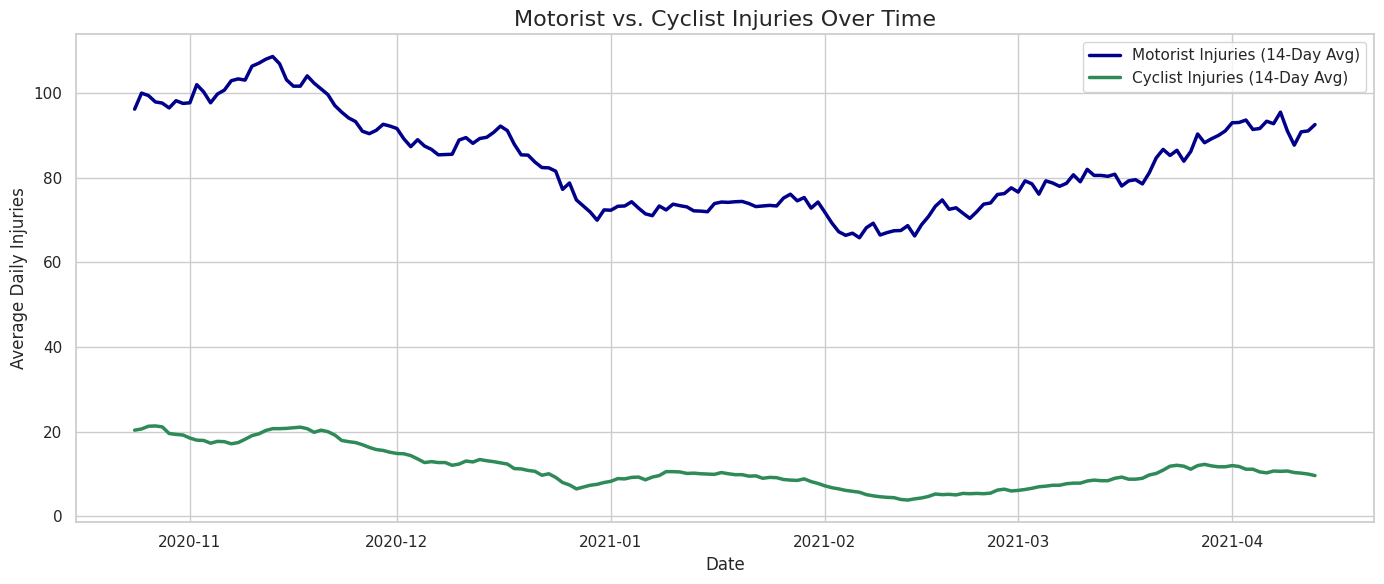

In [ ]:
import matplotlib.pyplot as plt
import seaborn as pd
import seaborn as sns
import pandas as pd


# 1. Resample by Day ('D') and sum the specific injuries
daily_injuries = tsa_df.resample('D')[['number_of_motorist_injured', 'number_of_cyclist_injured']].sum()

# 2. Apply a 14-Day Moving Average to smooth the daily noise
# (Using 14 instead of 30 so we don't trim too much of your 50k sample)
ma_injuries = daily_injuries.rolling(window=14).mean()

# 3. Plotting the Comparison
plt.figure(figsize=(14, 6))

# Plot Motorist Injuries
sns.lineplot(x=ma_injuries.index, y=ma_injuries['number_of_motorist_injured'],
             color='darkblue', linewidth=2.5, label='Motorist Injuries (14-Day Avg)')

# Plot Cyclist Injuries
sns.lineplot(x=ma_injuries.index, y=ma_injuries['number_of_cyclist_injured'],
             color='seagreen', linewidth=2.5, label='Cyclist Injuries (14-Day Avg)')

plt.title('Motorist vs. Cyclist Injuries Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Daily Injuries', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

### Conclusion:

Because the two lines move in tandem, this specific six-month window shows that winter weather suppresses overall travel and accidents across the board

# Advanced Trend

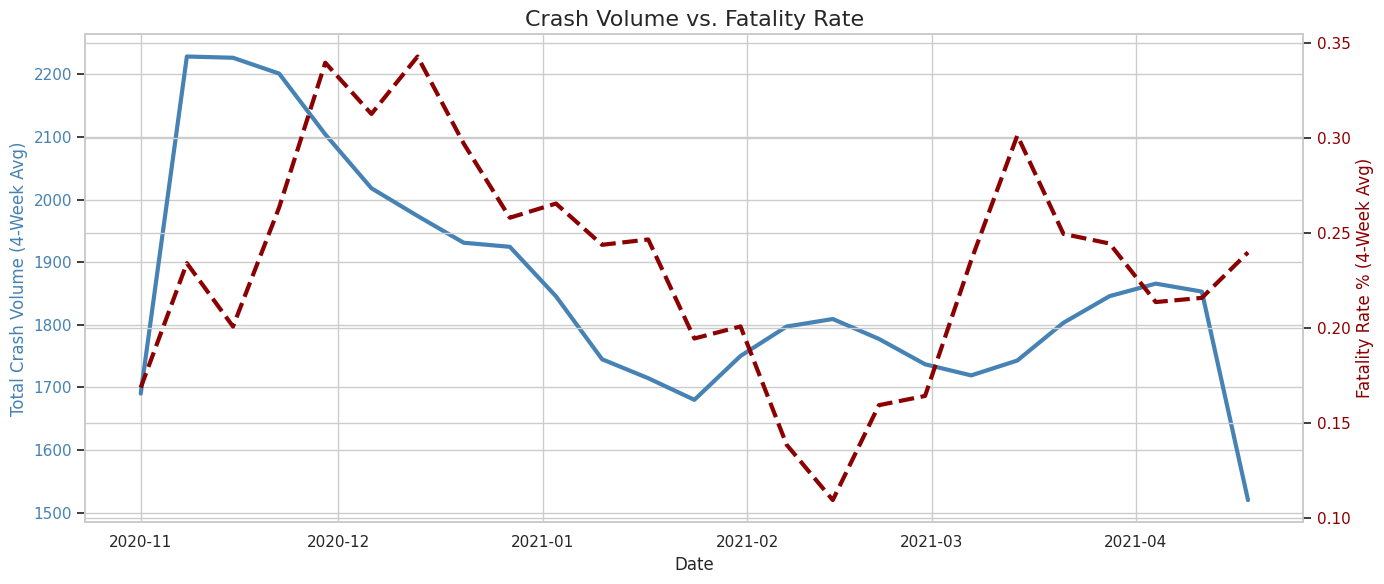

In [ ]:
# Set up the index and ensure numeric data
tsa_df = df.set_index('crash_date').sort_index()
tsa_df['number_of_persons_killed'] = pd.to_numeric(tsa_df['number_of_persons_killed'], errors='coerce').fillna(0)
tsa_df['number_of_motorist_injured'] = pd.to_numeric(tsa_df['number_of_motorist_injured'], errors='coerce').fillna(0)
tsa_df['number_of_cyclist_injured'] = pd.to_numeric(tsa_df['number_of_cyclist_injured'], errors='coerce').fillna(0)

sns.set_theme(style="whitegrid")

# 1. Resample by Week ('W')
weekly_volume = tsa_df.resample('W').size()
# Count how many crashes had at least 1 death
weekly_fatal_crashes = tsa_df['number_of_persons_killed'].apply(lambda x: 1 if x > 0 else 0).resample('W').sum()
paradox_df = pd.DataFrame({'Total_Crashes': weekly_volume, 'Fatal_Crashes': weekly_fatal_crashes})
# Filter out empty weeks to prevent division by zero
paradox_df = paradox_df[paradox_df['Total_Crashes'] > 0]
paradox_df['Fatality_Rate_Pct'] = (paradox_df['Fatal_Crashes'] / paradox_df['Total_Crashes']) * 100

# 3. Apply a 4-week moving average to smooth the noisy weekly data
paradox_df['Smoothed_Volume'] = paradox_df['Total_Crashes'].rolling(window=4).mean()
paradox_df['Smoothed_Rate'] = paradox_df['Fatality_Rate_Pct'].rolling(window=4).mean()

fig, ax1 = plt.subplots(figsize=(14, 6))
color1 = 'steelblue'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Total Crash Volume (4-Week Avg)', color=color1, fontsize=12)
ax1.plot(paradox_df.index, paradox_df['Smoothed_Volume'], color=color1, linewidth=3, label='Crash Volume')
ax1.tick_params(axis='y', labelcolor=color1)
ax2 = ax1.twinx()  # instantiates a second Y-axis sharing the same X-axis
color2 = 'darkred'
ax2.set_ylabel('Fatality Rate % (4-Week Avg)', color=color2, fontsize=12)
ax2.plot(paradox_df.index, paradox_df['Smoothed_Rate'], color=color2, linewidth=3, linestyle='--', label='Fatality Rate')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Crash Volume vs. Fatality Rate', fontsize=16)
fig.tight_layout()
plt.show()

### Conclusion

Crash volume and fatality rate do not move together consistently. Periods with fewer crashes can still show a higher fatality rate, particularly around December and March.

### A strong conclusion after checking history

The pandemic created an unusual road-safety pattern in NYC: fewer crashes did not necessarily mean fewer deaths. Reduced traffic was accompanied by more dangerous driving, particularly speeding, which helps explain why fatality rates could spike even when crash volumes were relatively low.

One important caveat: the chart shows an **association**, not proof that COVID-19 caused the spikes.

# Seasonality in Time Series Analysis

Seasonality is a pattern that repeats at a regular and predictable interval over time, such as daily, weekly, monthly, or yearly.

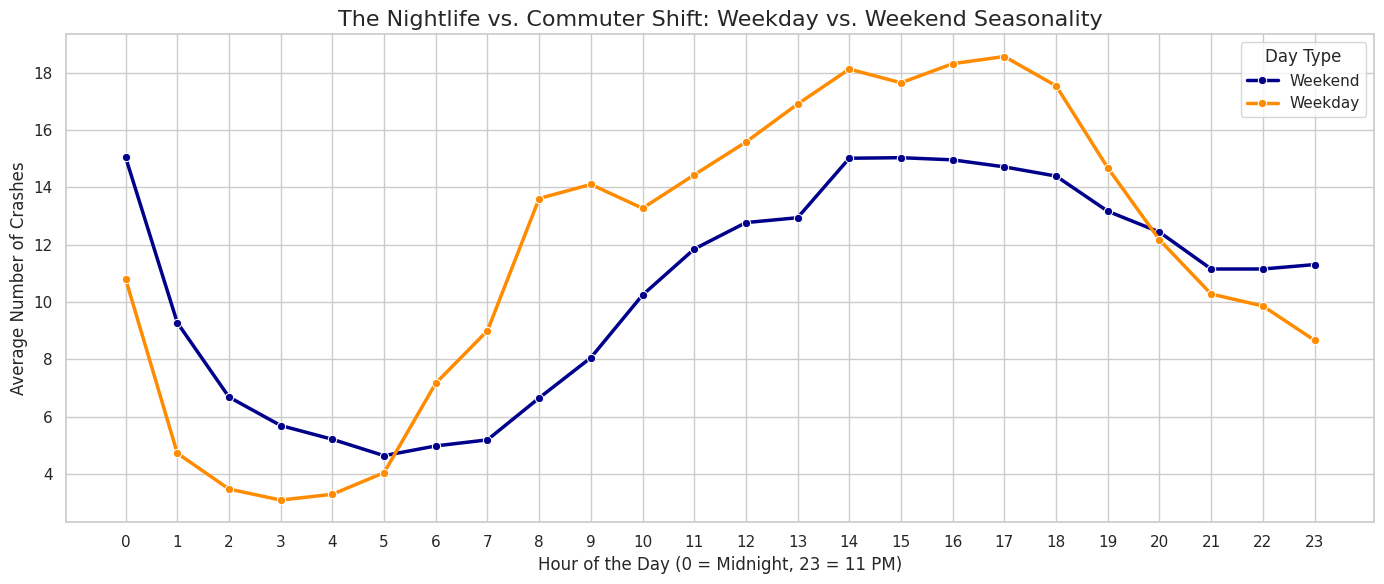

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Ensure the crash hour is extracted
df['crash_hour'] = df['crash_time'].apply(lambda x: x.hour if pd.notna(x) else None)

# 2. Categorize each date as a 'Weekday' or 'Weekend'
# .dt.dayofweek returns 0 for Monday through 6 for Sunday (5 and 6 are the weekend)
df['day_type'] = df['crash_date'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# 3. Group the data by specific date and hour to count exact crashes per hour, per day
# This prevents weekdays from looking artificially higher simply because there are 5 of them
hourly_daily_counts = df.groupby(['crash_date', 'crash_hour', 'day_type']).size().reset_index(name='crash_count')

# 4. Generate the Visualization
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# sns.lineplot automatically calculates the mathematical mean and draws the lines
sns.lineplot(
    data=hourly_daily_counts,
    x='crash_hour',
    y='crash_count',
    hue='day_type',
    palette=['darkblue', 'darkorange'], # Distinct colors for contrast
    linewidth=2.5,
    marker="o",
    errorbar=None # Hides the confidence interval shading for a cleaner look
)

plt.title("The Nightlife vs. Commuter Shift: Weekday vs. Weekend Seasonality", fontsize=16)
plt.xlabel("Hour of the Day (0 = Midnight, 23 = 11 PM)", fontsize=12)
plt.ylabel("Average Number of Crashes", fontsize=12)
plt.xticks(range(0, 24)) # Ensure every single hour is explicitly labeled
plt.legend(title='Day Type', fontsize=11)
plt.tight_layout()
plt.show()

### Conclusion

Weekdays show a clear commuter pattern, with crashes rising sharply after 6 AM and peaking around 2-5 PM.
Weekends show a different pattern, with higher crash levels around midnight and a more gradual rise through the day.

**The timing of crash risk shifts from late-night hours on weekends to daytime and evening hours on weekdays.**


**Note**: Crash counts were normalized by the number of weekdays and weekends to account for the **unequal number of days** in each group.

## SIDE QUEST: Just wanted to explore statsmodels library

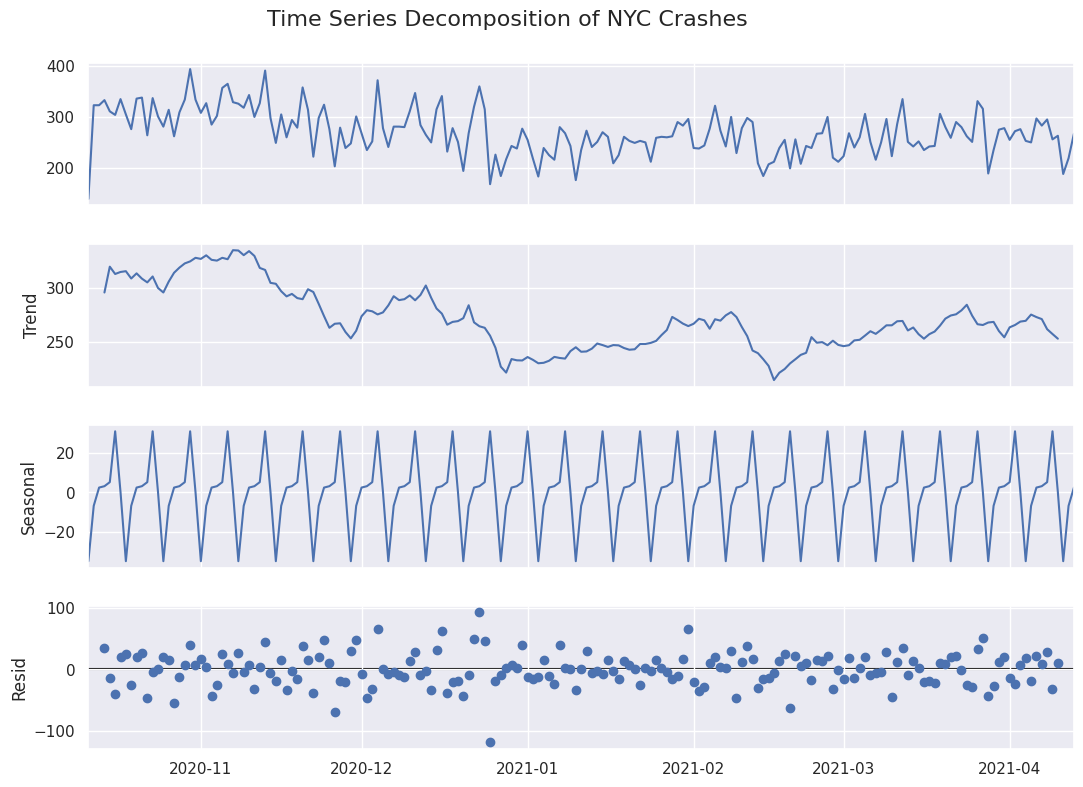

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# 1. Prepare the data: Get daily crash counts and fill any missing days with 0
daily_crashes = df.set_index('crash_date').resample('D').size()
daily_crashes = daily_crashes.asfreq('D', fill_value=0)

# Ensure there is enough data for a 7-day seasonal decomposition
if len(daily_crashes) > 14:
    # 2. Perform the decomposition (period=7 for weekly seasonality)
    decomposition = seasonal_decompose(daily_crashes, model='additive', period=7)

    # 3. Plot the 4-part TSA chart
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle('Time Series Decomposition of NYC Crashes', fontsize=16, y=1.02)
    plt.show()
else:
    print("Your 50k sample doesn't cover enough days to run a full decomposition. Try pulling more data!")

## I**MPORTANT: Crash Spike Analysis**

This analysis examines the days with unusually high crash counts and investigates what events or factors may have contributed to these spikes.


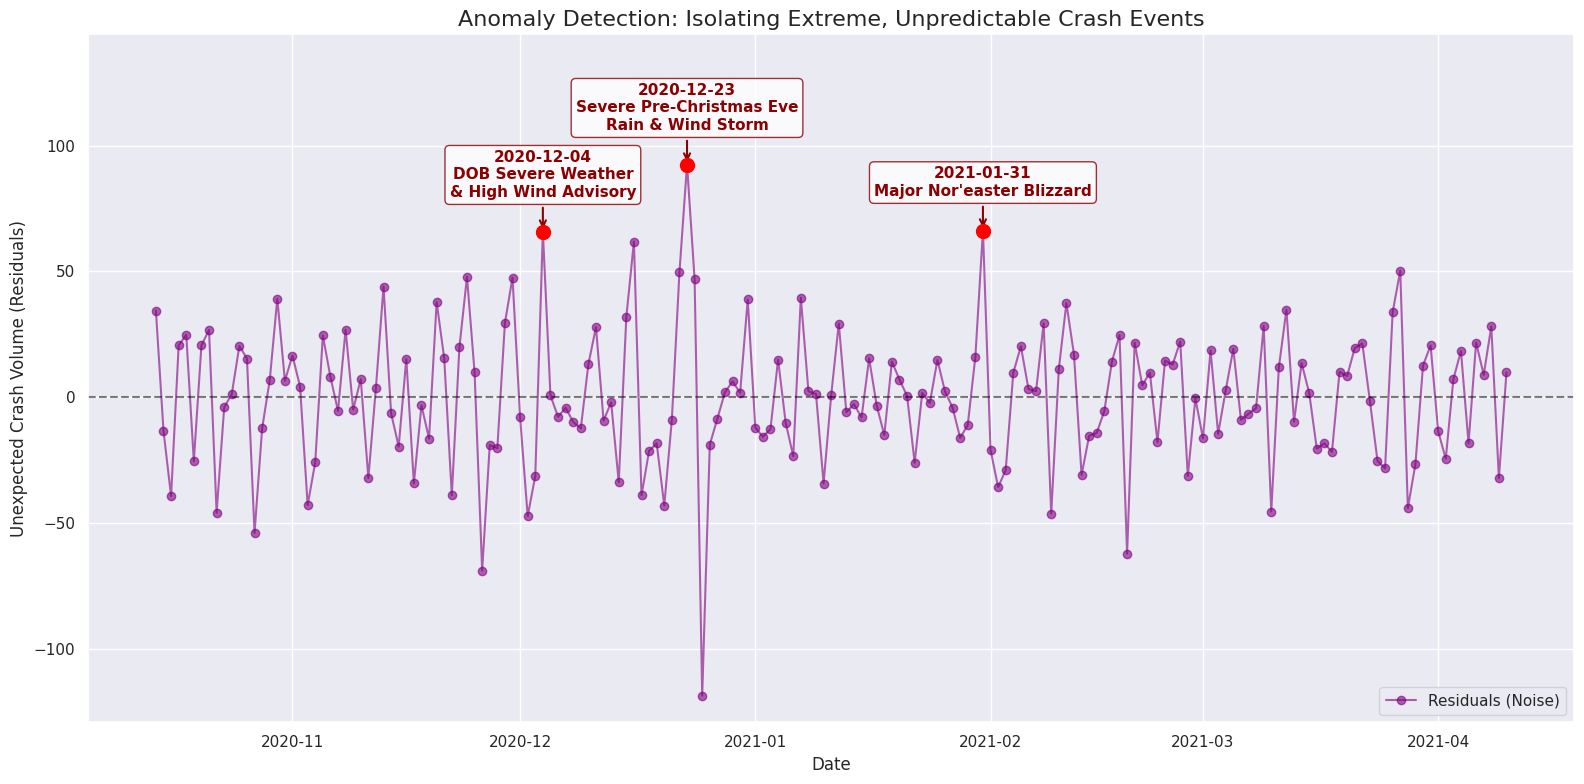

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import pandas as pd

# 1. Prepare the daily crash data
daily_crashes = df.set_index('crash_date').resample('D').size()
daily_crashes = daily_crashes.asfreq('D', fill_value=0)

# 2. Run the decomposition and isolate ONLY the residuals
decomposition = seasonal_decompose(daily_crashes, model='additive', period=7)
residuals = decomposition.resid.dropna()

# 3. Automatically find the top 3 highest anomaly spikes
top_anomalies = residuals.nlargest(3)

# 4. Generate the Anomaly Chart
# FIX 1: Made the figure slightly wider and taller (16x8 instead of 14x6)
plt.figure(figsize=(16, 8))
sns.set_theme(style="darkgrid")

# Plot the baseline residual noise in purple
plt.plot(residuals.index, residuals.values, color='purple', marker='o', linestyle='-', alpha=0.6, label='Residuals (Noise)')

# Loop through the top 3 anomalies to draw red dots and text labels
for date, value in top_anomalies.items():
    plt.scatter(date, value, color='red', s=100, zorder=5)

    date_str = date.strftime('%Y-%m-%d')

    # Apply the specific historical labels
    if date_str == '2021-01-31':
        event_name = "Major Nor'easter Blizzard"
    elif date_str == '2020-12-23':
        event_name = "Severe Pre-Christmas Eve\nRain & Wind Storm"
    elif date_str == '2020-12-04':
        event_name = "DOB Severe Weather\n& High Wind Advisory"
    else:
        event_name = "Unidentified Anomaly"

    event_text = f"{date_str}\n{event_name}"

    # Draw the text
    plt.annotate(
        event_text,
        xy=(date, value),
        xytext=(0, 25), # Pushed slightly higher above the dot
        textcoords='offset points',
        ha='center',
        fontsize=11,
        fontweight='bold',
        color='darkred',
        arrowprops=dict(arrowstyle="->", color='darkred', lw=1.5),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", alpha=0.8) # Added a white background box to make text pop
    )

# Draw a baseline at 0
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("Anomaly Detection: Isolating Extreme, Unpredictable Crash Events", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Unexpected Crash Volume (Residuals)", fontsize=12)
plt.legend(loc='lower right') # Moved legend out of the way

# FIX 2: Dynamically scale the Y-axis to add 40% more "headroom" at the top of the chart
y_min, y_max = plt.ylim()
plt.ylim(y_min, y_max * 1.4)

plt.tight_layout()
plt.show()

In [ ]:
print("--- Looking out for these dates!---")
print(top_anomalies)
print("\n")


--- Looking out for these dates!---
crash_date
2020-12-23    92.463799
2021-01-31    66.269513
2020-12-04    65.842920
Name: resid, dtype: float64




January 31, 2021 (2021-01-31)
The Event: A massive, multi-day Nor'easter Blizzard.
What Happened: This was one of the largest winter storms in NYC history, dropping 17.4 inches of snow in Central Park. A state of emergency was declared.


December 23, 2020 (2020-12-23)
The Event: Severe Pre-Christmas Eve Rain & Wind Storm.
What Happened: A violent storm system moved through the Tri-State area right before the holiday, prompting High Wind Warnings and Flash Flood Watches for NYC, Long Island, and coastal areas.

December 4, 2020 (2020-12-04)
The Event: Heavy Rain & High Wind Advisory.
What Happened: A severe weather system hit the city, prompting the NYC Department of Buildings to issue an official Weather Advisory for high winds (up to 40 MPH) and heavy rain going into the weekend.

In [ ]:
import pandas as pd

# 1. Clean up casualty numbers and street text
casualty_cols = [
    'number_of_persons_injured', 'number_of_persons_killed',
    'number_of_pedestrians_injured', 'number_of_pedestrians_killed',
    'number_of_cyclist_injured', 'number_of_cyclist_killed',
    'number_of_motorist_injured', 'number_of_motorist_killed'
]

for col in casualty_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Filter out rows missing intersection street names
intersections = df.dropna(subset=['on_street_name', 'cross_street_name']).copy()

# Standardize whitespace and casing for consistent grouping
intersections['on_street_name'] = intersections['on_street_name'].str.strip().str.upper()
intersections['cross_street_name'] = intersections['cross_street_name'].str.strip().str.upper()
intersections['borough'] = intersections['borough'].fillna('UNKNOWN').str.strip().str.upper()

# Ensure street order doesn't split identical intersections (e.g., "5th Ave & 42nd St" vs "42nd St & 5th Ave")
def build_intersection_key(row):
    streets = sorted([row['on_street_name'], row['cross_street_name']])
    return f"{streets[0]} & {streets[1]}"

intersections['intersection'] = intersections.apply(build_intersection_key, axis=1)

# 2. Aggregate metrics by intersection and borough
intersection_stats = intersections.groupby(['intersection', 'borough']).agg(
    total_crashes=('crash_date', 'count'),
    total_killed=('number_of_persons_killed', 'sum'),
    total_injured=('number_of_persons_injured', 'sum'),
    pedestrians_killed=('number_of_pedestrians_killed', 'sum'),
    cyclists_killed=('number_of_cyclist_killed', 'sum'),
    motorists_killed=('number_of_motorist_killed', 'sum'),
    latitude=('latitude', 'mean'),
    longitude=('longitude', 'mean')
).reset_index()

# 3. Create a composite Severity Score
# Weighted index: 1 crash = 1 pt, 1 injury = 3 pts, 1 fatality = 10 pts
intersection_stats['severity_score'] = (
    intersection_stats['total_crashes'] * 1 +
    intersection_stats['total_injured'] * 3 +
    intersection_stats['total_killed'] * 10
)

# 4. Extract Top 10 Deadliest Intersections
deadliest_intersections = intersection_stats.sort_values(
    by=['total_killed', 'severity_score', 'total_crashes'],
    ascending=False
).head(10).reset_index(drop=True)

# Format and display
display_cols = [
    'intersection', 'borough', 'total_crashes',
    'total_killed', 'total_injured', 'severity_score'
]

print("Top 10 Deadliest/Most Dangerous Intersections:")
print(deadliest_intersections[display_cols].to_string(index=False))

Top 10 Deadliest/Most Dangerous Intersections:
                         intersection       borough  total_crashes  total_killed  total_injured  severity_score
           BELT PARKWAY & UNSPECIFIED   UNSPECIFIED            893             7          590.0          2733.0
     BRUCKNER BOULEVARD & UNSPECIFIED   UNSPECIFIED            103             4           44.0           275.0
               1 AVENUE & UNSPECIFIED     MANHATTAN             68             3           31.0           191.0
 LONG ISLAND EXPRESSWAY & UNSPECIFIED   UNSPECIFIED            482             2          252.0          1258.0
MAJOR DEEGAN EXPRESSWAY & UNSPECIFIED   UNSPECIFIED            378             2          189.0           965.0
    PENNSYLVANIA AVENUE & UNSPECIFIED      BROOKLYN            116             2           56.0           304.0
        HYLAN BOULEVARD & UNSPECIFIED STATEN ISLAND             87             2           35.0           212.0
             164 STREET & UNSPECIFIED        QUEENS      

## **Heatmap Interpretation**

The heatmap was used to visually map the locations of crashes identified in the top **10 most dangerous intersections**. Darker and more concentrated areas indicate locations with a higher concentration of crashes, helping identify geographic hotspots that are difficult to see from the table alone.

Folium is a Python library that acts as a translator between your data environment and Leaflet.js, a widely used open-source JavaScript library for interactive web maps

In [ ]:
import folium

# Center around NYC average coordinates
nyc_center = [40.7128, -74.0060]
intersection_map = folium.Map(location=nyc_center, zoom_start=11, tiles='Cartodb_Voyager')

for _, row in deadliest_intersections.iterrows():
    # Only map if valid coordinates exist
    if pd.notna(row['latitude']) and pd.notna(row['longitude']):
        popup_text = f"""
        <b>{row['intersection']}</b><br>
        Borough: {row['borough']}<br>
        Fatalities: {int(row['total_killed'])}<br>
        Injuries: {int(row['total_injured'])}<br>
        Total Crashes: {int(row['total_crashes'])}<br>
        Severity Score: {int(row['severity_score'])}
        """
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=6 + (row['total_killed'] * 4), # Larger radius for fatal hotspots
            color='darkred',
            fill=True,
            fill_color='red',
            fill_opacity=0.8,
            popup=folium.Popup(popup_text, max_width=250)
        ).add_to(intersection_map)

intersection_map

### The spatial analysis reveals clear crash hotspots across the NYC region, with several high-volume locations concentrated along major roadways.

The crash hotspots are not evenly distributed across the NYC area. The largest clusters appear around Brooklyn, Queens, the Bronx, and parts of Staten Island, while Manhattan has fewer large hotspots in comparison.

NOTE: During the geospatial analysis, a clear data anomaly appeared on the map: 893 crashes were grouped under “BELT PARKWAY & UNSPECIFIED.” This happens because intersection-based grouping works well for city streets but breaks down on major highways, where crashes may not have a traditional cross-street listed.

Since the mapping process groups records using these text labels and then calculates the average GPS coordinates, crashes that occurred at different locations along the Belt Parkway were combined into a single point. This created an artificial “mega-intersection” on the map.

In [ ]:
import folium
import pandas as pd

# 1. Clean the geospatial and numerical data
geo_df = df.dropna(subset=['latitude', 'longitude']).copy()
geo_df['latitude'] = pd.to_numeric(geo_df['latitude'], errors='coerce')
geo_df['longitude'] = pd.to_numeric(geo_df['longitude'], errors='coerce')
geo_df['number_of_persons_killed'] = pd.to_numeric(geo_df['number_of_persons_killed'], errors='coerce').fillna(0)
geo_df['number_of_persons_injured'] = pd.to_numeric(geo_df['number_of_persons_injured'], errors='coerce').fillna(0)

# 2. Filter out bad coordinates outside NYC bounds
geo_df = geo_df[(geo_df['latitude'] > 40.5) & (geo_df['latitude'] < 41.0) &
                (geo_df['longitude'] > -74.3) & (geo_df['longitude'] < -73.7)]

# 3. Categorize crashes by severity
fatal_crashes = geo_df[geo_df['number_of_persons_killed'] > 0]
injury_crashes = geo_df[(geo_df['number_of_persons_injured'] > 0) & (geo_df['number_of_persons_killed'] == 0)]
fender_benders = geo_df[(geo_df['number_of_persons_injured'] == 0) & (geo_df['number_of_persons_killed'] == 0)]

# 4. Sample non-fatal crashes to prevent browser memory overload
# We plot ALL fatalities, but limit the others to 2,000 points each
sampled_injuries = injury_crashes.sample(min(2000, len(injury_crashes)), random_state=42)
sampled_fenders = fender_benders.sample(min(2000, len(fender_benders)), random_state=42)

# Initialize the base map using Esri's free Light Gray Canvas tiles
severity_map = folium.Map(
    location=[40.7128, -74.0060],
    zoom_start=11,
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}',
    attr='Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ'
)

# 6. Create Feature Groups (This allows you to toggle layers on and off)
fender_group = folium.FeatureGroup(name='Property Damage / Fender Benders (Grey)')
injury_group = folium.FeatureGroup(name='Injury Crashes (Orange)')
fatal_group = folium.FeatureGroup(name='Fatal Crashes (Red)')

# Plot Fender Benders (Small grey dots)
for _, row in sampled_fenders.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2, color='gray', fill=True, fill_opacity=0.3, weight=0
    ).add_to(fender_group)

# Plot Injury Crashes (Medium orange dots)
for _, row in sampled_injuries.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4, color='darkorange', fill=True, fill_opacity=0.6, weight=0
    ).add_to(injury_group)

# Plot Fatal Crashes (Large red dots)
for _, row in fatal_crashes.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=8, color='darkred', fill=True, fill_color='red', fill_opacity=0.9, weight=1
    ).add_to(fatal_group)

# 7. Add all groups to the map and enable the interactive layer control
fender_group.add_to(severity_map)
injury_group.add_to(severity_map)
fatal_group.add_to(severity_map)

# This adds the toggle menu in the top right corner
folium.LayerControl(position='topright').add_to(severity_map)

# Display the map
severity_map

Based on the spatial distribution in the map, several patterns stand out:

* **Manhattan shows high crash volume but fewer fatal crashes relative to that volume.** The dense concentration of injury crashes contrasts with the smaller number of fatal crashes. Lower vehicle speeds and heavy traffic may contribute to this pattern, but the map alone cannot establish the cause.

* **Fatal crashes are more dispersed across the outer boroughs**, particularly Brooklyn, Queens, and the Bronx. Staten Island also shows several fatal crashes despite having fewer overall crash locations.

* **Crash volume and fatality do not necessarily move together.** Fatal crashes appear along major expressways and wider arterial roads, suggesting that road type and driving conditions may be important factors in crash severity.

# <font color='lightblue'>**Overall Project Conclusion**</font>
# What the data tells us



The analysis reveals that crashes are driven by a combination of human behavior, time of day, road environment, and location.

1. Driver behavior is the clearest factor.
Driver inattention/distraction is by far the largest recorded contributing factor, with roughly 12,000 crashes in the analyzed sample.

2. Crash timing follows recognizable patterns.
The hourly analysis shows that crashes increase during the day and reach their highest levels during the afternoon and early evening. When weekday and weekend data are normalized, the difference becomes more interesting: weekdays show a commuter-related pattern, while weekends have relatively higher crash activity during late-night and early-morning hours.

3. More crashes does not automatically mean more severe crashes.
The crash-volume versus fatality-rate analysis shows that periods with fewer crashes can still have a higher fatality rate. Looking only at crash counts would therefore miss an important part of the safety picture.

4. Vehicle counts need context.
Sedans and SUVs account for the largest number of crashes. But this does not mean they are inherently more dangerous. There may simply be many more of these vehicles on NYC roads.

5. Geography reveals concentrated hotspots.
The Folium analysis shows that crashes are concentrated around particular roads and locations rather than being evenly distributed across NYC. These locations could be investigated further for factors such as road design, speed, traffic volume, lighting, and intersection structure.



# <font color='lightblue'>**The central finding is that understanding road safety requires looking beyond how many crashes occur and examining when they occur, why they occur, where they occur, and how severe their outcomes are.**</font>